# Pipeline 5: In-Kind Donation Value Prediction

## Problem framing

**Business question:** Can we predict in-kind donation value at intake time, and what item/donor attributes are associated with higher value?

**Unit of analysis:** One row per in-kind donation event (donation-level aggregate).

**Target:** `total_value_php = sum(quantity * estimated_unit_value)` per donation, modeled as `log_total_value = log1p(total_value_php)`.

**Predictive goal:** Intake valuation tool at receipt time.

**Explanatory goal:** OLS on log donation value for interpretable associations.

**Sample-size rule:** Compact predictive feature set (<=9) for N~98.

**Causal note:** Explanatory findings are associative, not causal.


## Data Preparation

This section loads source tables, joins data, and engineers model features.


## EDA

This section explores target distributions and key feature patterns that inform modeling choices.


## Predictive Modeling

This section trains and compares predictive models using the pipeline-specific validation strategy.


## Explanatory Modeling

This section fits an interpretable model and summarizes top associative findings.


## Feature Selection

This section documents what was dropped, what was retained, and why.


## Deployment Function

This section exposes a prediction function and example usage.


This model does two things. First, it predicts the likely value of an in-kind donation when it arrives, so staff can plan resources quickly. Second, it shows which donation patterns are linked to higher value, like item mix, quantity, condition, and donor profile. The results are useful for intake planning and donor segmentation, but they should be treated as associations, not proof that one factor directly causes higher value.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Keep notebook output clean
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

plt.savefig = lambda *args, **kwargs: None

from pathlib import Path
import os

def _resolve_data_path():
    env_path = os.getenv('LIGHTHOUSE_DATA_PATH')
    if env_path and Path(env_path).exists():
        return Path(env_path)

    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / 'lighthouse_csv_v7'
        if candidate.exists():
            return candidate

    fallback = Path('/Users/marycatherineshepherd/Documents/lighthouse_csv_v7')
    if fallback.exists():
        return fallback

    raise FileNotFoundError(
        "Could not locate 'lighthouse_csv_v7'. Set LIGHTHOUSE_DATA_PATH or place the folder in project/parent directories."
    )

DATA_PATH = str(_resolve_data_path()) + '/'



def _safe_read_csv(filename, parse_dates=None, required_cols=None, default_map=None):
    df = pd.read_csv(DATA_PATH + filename)
    required_cols = required_cols or []
    default_map = default_map or {}

    missing_cols = []
    for c in required_cols:
        if c not in df.columns:
            df[c] = default_map.get(c, np.nan)
            missing_cols.append(c)

    for c, v in default_map.items():
        if c in df.columns:
            df[c] = df[c].fillna(v)

    missing_date_cols = []
    if parse_dates:
        for c in parse_dates:
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], errors='coerce')
            else:
                missing_date_cols.append(c)

    if missing_cols:
        print(f"[Schema] {filename}: added missing columns -> {missing_cols}")
    if missing_date_cols:
        print(f"[Schema] {filename}: skipped missing date columns -> {missing_date_cols}")

    return df


# --- Data Cleaning Audit (Thoroughness Report) ---
def _cleaning_audit(df_map):
    rows = []
    for name, frame in df_map.items():
        miss = int(frame.isna().sum().sum())
        miss_pct = float((frame.isna().mean().mean() * 100) if len(frame.columns) else 0)
        rows.append({
            'table': name,
            'rows': int(len(frame)),
            'cols': int(frame.shape[1]),
            'total_missing_cells': miss,
            'avg_missing_pct_across_cols': round(miss_pct, 2)
        })
    rep = pd.DataFrame(rows).sort_values('table')
    print(rep)
    return rep


In [2]:
items = _safe_read_csv(
    'in_kind_donation_items.csv',
    required_cols=['donation_id','item_id','item_category','quantity','estimated_unit_value','intended_use','received_condition']
)
donations = _safe_read_csv(
    'donations.csv',
    parse_dates=['donation_date'],
    required_cols=['donation_id','supporter_id','donation_type','donation_date','campaign_name','channel_source']
)
supporters = _safe_read_csv(
    'supporters.csv',
    parse_dates=['created_at'],
    required_cols=['supporter_id','relationship_type','acquisition_channel','created_at']
)

inkind = donations[donations['donation_type'] == 'InKind'].copy()
a = items.copy()
a['line_value_php'] = pd.to_numeric(a['quantity'], errors='coerce').fillna(0) * pd.to_numeric(a['estimated_unit_value'], errors='coerce').fillna(0)

agg = a.groupby('donation_id').agg(
    total_value_php=('line_value_php','sum'),
    num_line_items=('item_id','count'),
    total_quantity=('quantity','sum'),
    intended_use_diversity=('intended_use', pd.Series.nunique)
).reset_index()
cat_mode = a.groupby('donation_id')['item_category'].agg(lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan).rename('primary_item_category').reset_index()
pct_new = a.assign(is_new=(a['received_condition'] == 'New').astype(int)).groupby('donation_id')['is_new'].mean().rename('pct_items_new').reset_index()
cond_mode = a.groupby('donation_id')['received_condition'].agg(lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan).rename('received_condition_mode').reset_index()

df = inkind.merge(agg, on='donation_id', how='left').merge(cat_mode, on='donation_id', how='left').merge(pct_new, on='donation_id', how='left').merge(cond_mode, on='donation_id', how='left')
df = df.merge(supporters[['supporter_id','relationship_type','acquisition_channel','created_at']], on='supporter_id', how='left')

df = df.sort_values('donation_date').copy()
df['prior_count'] = df.groupby('supporter_id').cumcount()
df['prior_inkind_avg_value'] = df.groupby('supporter_id')['total_value_php'].apply(lambda s: s.shift(1).expanding().mean()).reset_index(level=0, drop=True)
df['is_repeat_inkind_donor'] = (df['prior_count'] > 0).astype(int)
df['prior_inkind_avg_value'] = df['prior_inkind_avg_value'].fillna(0)

df['days_as_supporter'] = (df['donation_date'] - df['created_at']).dt.days.clip(lower=0)
df['month_of_year'] = df['donation_date'].dt.month
df['campaign_active'] = df['campaign_name'].notna().astype(int)
df['total_value_php'] = df['total_value_php'].fillna(0)
df['log_total_value'] = np.log1p(df['total_value_php'])

print('N:', len(df))
print(df[['total_value_php','log_total_value']].describe())


N: 98
       total_value_php  log_total_value
count        98.000000        98.000000
mean      11515.910918         8.767299
std       10142.356727         1.418601
min          13.680000         2.686486
25%        3699.900000         8.216025
50%        8748.275000         9.076724
75%       15926.325000         9.675791
max       50602.480000        10.831776


In [3]:
CLEANING_AUDIT = _cleaning_audit({'items': items, 'donations': donations, 'supporters': supporters, 'model_df': df})


        table  rows  cols  total_missing_cells  avg_missing_pct_across_cols
1   donations   420    13                  990                        18.13
0       items   129     9                    0                         0.00
3    model_df    98    30                  339                        11.53
2  supporters    60    15                   65                         7.22


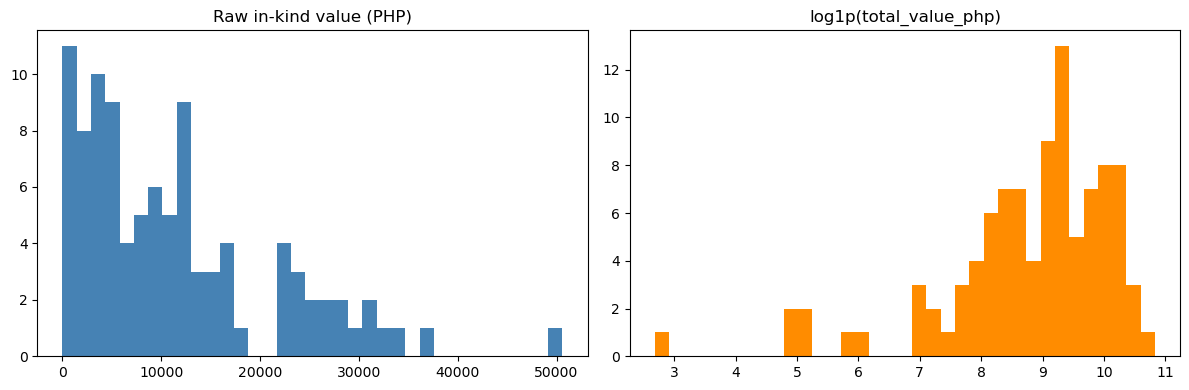

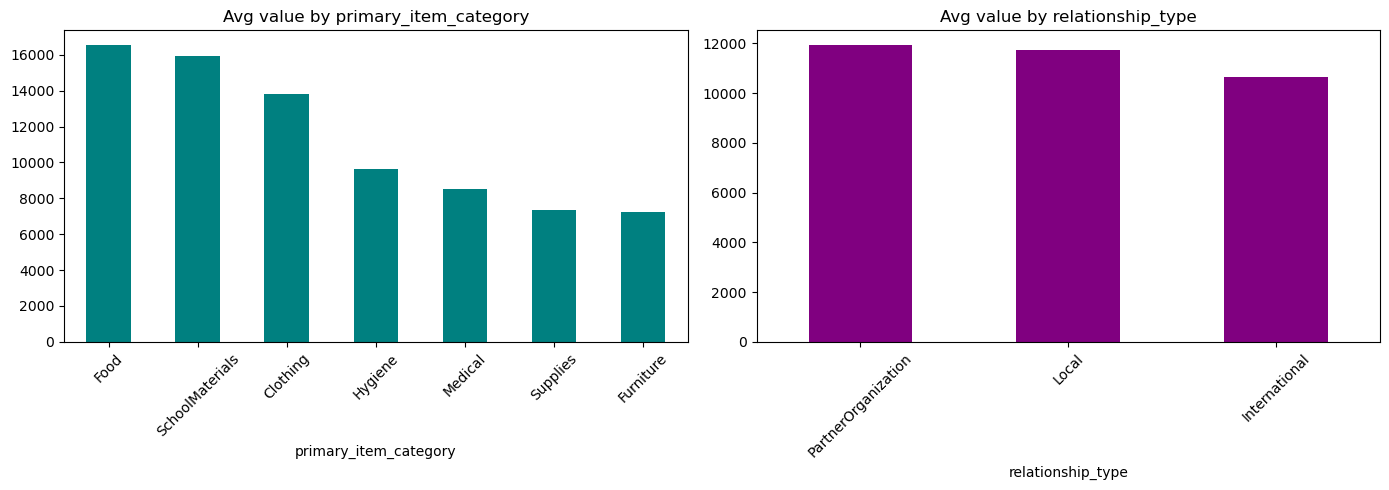

In [4]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(df['total_value_php'], bins=35, color='steelblue')
axes[0].set_title('Raw in-kind value (PHP)')
axes[1].hist(df['log_total_value'], bins=35, color='darkorange')
axes[1].set_title('log1p(total_value_php)')
plt.tight_layout()
plt.show()

cat_avg = df.groupby('primary_item_category', dropna=False)['total_value_php'].mean().sort_values(ascending=False).head(12)
rel_avg = df.groupby('relationship_type', dropna=False)['total_value_php'].mean().sort_values(ascending=False)
fig, axes = plt.subplots(1,2, figsize=(14,5))
cat_avg.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Avg value by primary_item_category')
axes[0].tick_params(axis='x', rotation=45)
rel_avg.plot(kind='bar', ax=axes[1], color='purple')
axes[1].set_title('Avg value by relationship_type')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


In [5]:
predictive_features=['primary_item_category','num_line_items','total_quantity','pct_items_new','intended_use_diversity','relationship_type','is_repeat_inkind_donor','prior_inkind_avg_value','campaign_active']
X = df[predictive_features].copy()
y = pd.to_numeric(df['log_total_value'], errors='coerce').fillna(0.0)

# Explicit schema (prevents strings entering numeric imputer)
cat_cols = ['primary_item_category', 'relationship_type']
num_cols = [
    'num_line_items', 'total_quantity', 'pct_items_new', 'intended_use_diversity',
    'is_repeat_inkind_donor', 'prior_inkind_avg_value', 'campaign_active'
]

# Clean numeric columns
for c in num_cols:
    X[c] = pd.to_numeric(X[c], errors='coerce')

# Clean categorical columns
for c in cat_cols:
    X[c] = X[c].fillna('Missing').astype(str)

prep = ColumnTransformer([
    ('num', Pipeline([('imp',SimpleImputer(strategy='median')),('sc',StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp',SimpleImputer(strategy='most_frequent')),('oh',OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

models={
    'LinearRegression':LinearRegression(),
    'RandomForest':RandomForestRegressor(n_estimators=300, random_state=42, min_samples_leaf=3),
    'GradientBoosting':GradientBoostingRegressor(random_state=42)
}

cv=KFold(n_splits=5, shuffle=True, random_state=42)

# sklearn-version-safe scorer (no squared=False)
def _rmse_score(yt, yp):
    yt = pd.to_numeric(pd.Series(yt), errors='coerce')
    yp = pd.to_numeric(pd.Series(yp), errors='coerce')
    mask = yt.notna() & yp.notna()
    if mask.sum() == 0:
        return np.nan
    return float(np.sqrt(mean_squared_error(yt[mask], yp[mask])))

rmse_scorer = make_scorer(_rmse_score, greater_is_better=False)


In [6]:
rows=[]; trained={}
with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    for n,m in models.items():
        pipe=Pipeline([('prep',prep),('model',m)])
        scores=cross_validate(
            pipe,
            X,
            y,
            cv=cv,
            scoring={'rmse_log':rmse_scorer,'r2':'r2'},
            error_score='raise'
        )
        rmse=-scores['test_rmse_log']
        r2=scores['test_r2']
        rows.append({
            'model':n,
            'rmse_log_mean':float(np.nanmean(rmse)),
            'rmse_log_std':float(np.nanstd(rmse)),
            'r2_mean':float(np.nanmean(r2)),
            'r2_std':float(np.nanstd(r2)),
            'rmse_php_approx':float(np.expm1(np.nanmean(rmse)))
        })
        pipe.fit(X,y)
        trained[n]=pipe

results=pd.DataFrame(rows).sort_values('rmse_log_mean')
print(results)
BEST_MODEL_NAME=results.iloc[0]['model']
FINAL_MODEL=trained[BEST_MODEL_NAME]
print('Selected predictive model:', BEST_MODEL_NAME)


              model  rmse_log_mean  rmse_log_std   r2_mean    r2_std  \
0  LinearRegression       1.395567      0.685310  0.125963  0.330643   
1      RandomForest       1.500143      0.549385  0.473558  0.099354   
2  GradientBoosting       1.563857      0.596235  0.254371  0.319182   

   rmse_php_approx  
0         3.037262  
1         3.482331  
2         3.777213  
Selected predictive model: LinearRegression


In [7]:
expl_cols=['primary_item_category','num_line_items','total_quantity','pct_items_new','intended_use_diversity','received_condition_mode','relationship_type','acquisition_channel','is_repeat_inkind_donor','prior_inkind_avg_value','days_as_supporter','month_of_year','campaign_active','channel_source']
expl=df[expl_cols+['log_total_value']].copy()

expl_num_cols=['num_line_items','total_quantity','pct_items_new','intended_use_diversity','is_repeat_inkind_donor','prior_inkind_avg_value','days_as_supporter','month_of_year','campaign_active']
expl_cat_cols=[c for c in expl_cols if c not in expl_num_cols]

for c in expl_num_cols:
    if c not in expl.columns:
        expl[c]=np.nan
    expl[c]=pd.to_numeric(expl[c], errors='coerce')
    med=expl[c].median(skipna=True)
    if pd.isna(med):
        med=0.0
    expl[c]=expl[c].replace([np.inf,-np.inf], np.nan).fillna(med)

for c in expl_cat_cols:
    if c not in expl.columns:
        expl[c]='Missing'
    expl[c]=expl[c].fillna('Missing').astype(str)

X_num=expl[expl_num_cols].astype(float)
X_cat=pd.get_dummies(expl[expl_cat_cols], drop_first=True, dtype=float)
X_expl=pd.concat([X_num, X_cat], axis=1)
X_expl=sm.add_constant(X_expl, has_constant='add')
X_expl=X_expl.apply(pd.to_numeric, errors='coerce').fillna(0.0).astype(float)

y_expl=pd.to_numeric(expl['log_total_value'], errors='coerce').replace([np.inf,-np.inf], np.nan)
mask=y_expl.notna()
X_expl=X_expl.loc[mask].copy()
y_expl=y_expl.loc[mask].astype(float)

if len(y_expl)==0:
    raise ValueError('No valid rows for explanatory OLS after preprocessing.')

ols=sm.OLS(y_expl, X_expl).fit()
print(ols.summary())

coef=ols.params.drop('const', errors='ignore')
pvals=ols.pvalues.drop('const', errors='ignore')
coef_df=pd.DataFrame({'coef_log':coef,'pvalue':pvals}).sort_values('coef_log', key=lambda s:s.abs(), ascending=False)
print('Top 3 associations with in-kind donation value (associative):')
for idx,row in coef_df.head(3).iterrows():
    pct=(np.exp(row['coef_log'])-1)*100
    print(f"- {idx}: approx {pct:.1f}% value difference, p={row['pvalue']:.3f}")


                            OLS Regression Results                            
Dep. Variable:        log_total_value   R-squared:                       0.581
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     3.423
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           1.72e-05
Time:                        12:02:25   Log-Likelihood:                -130.15
No. Observations:                  98   AIC:                             318.3
Df Residuals:                      69   BIC:                             393.3
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [8]:
selection = pd.DataFrame([
    ('received_condition_mode','Dropped from predictive','Keep predictive model compact for N~98'),
    ('acquisition_channel','Dropped from predictive','Useful in explanatory model; sparse for compact predictor set'),
    ('month_of_year','Dropped from predictive','Weak incremental signal in small sample'),
    ('channel_source','Dropped from predictive','Sparse categories in small sample')
], columns=['feature','decision','reason'])
print(selection)
print('Final predictive feature count:', len(predictive_features))


                   feature                 decision  \
0  received_condition_mode  Dropped from predictive   
1      acquisition_channel  Dropped from predictive   
2            month_of_year  Dropped from predictive   
3           channel_source  Dropped from predictive   

                                              reason  
0             Keep predictive model compact for N~98  
1  Useful in explanatory model; sparse for compac...  
2            Weak incremental signal in small sample  
3                  Sparse categories in small sample  
Final predictive feature count: 9


In [9]:
# --- Deployment Function (SQLite-backed) ---
import json
import sqlite3
from datetime import datetime
from pathlib import Path


def _deployment_db_path():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / 'ml-pipelines'
        if candidate.exists():
            return candidate / 'deployment_predictions.sqlite'
    return cwd / 'deployment_predictions.sqlite'


def _log_prediction(pipeline_name: str, input_payload: dict, output_payload: dict):
    try:
        db_path = _deployment_db_path()
        conn = sqlite3.connect(str(db_path))
        conn.execute("CREATE TABLE IF NOT EXISTS prediction_logs (id INTEGER PRIMARY KEY AUTOINCREMENT, pipeline TEXT NOT NULL, created_at TEXT NOT NULL, input_json TEXT NOT NULL, output_json TEXT NOT NULL)")
        cur = conn.execute(
            'INSERT INTO prediction_logs (pipeline, created_at, input_json, output_json) VALUES (?, ?, ?, ?)',
            (
                pipeline_name,
                datetime.utcnow().isoformat(timespec='seconds') + 'Z',
                json.dumps(input_payload, default=str),
                json.dumps(output_payload, default=str),
            )
        )
        conn.commit()
        conn.close()
        return int(cur.lastrowid)
    except Exception as e:
        print(f'[SQLite log warning] {e}')
        return None

FINAL_FEATURES = predictive_features


# Keep prediction inputs aligned with the training schema
def _prepare_predict_row(input_data: dict):
    row = pd.DataFrame([{f: input_data.get(f, np.nan) for f in FINAL_FEATURES}])
    for c in ['num_line_items', 'total_quantity', 'pct_items_new', 'intended_use_diversity', 'is_repeat_inkind_donor', 'prior_inkind_avg_value', 'campaign_active']:
        row[c] = pd.to_numeric(row[c], errors='coerce')
    for c in ['primary_item_category', 'relationship_type']:
        row[c] = row[c].fillna('Missing').astype(str)
    return row


def predict_inkind_value(input_data: dict):
    row = _prepare_predict_row(input_data)
    pred_log = float(FINAL_MODEL.predict(row)[0])
    pred_php = max(0.0, float(np.expm1(pred_log)))
    result = {
        'predicted_log_value': round(pred_log, 4),
        'predicted_value_php': round(pred_php, 2)
    }
    result['prediction_log_id'] = _log_prediction('in-kind-donation-value-prediction', input_data, result)
    return result


example = {
    'primary_item_category': 'SchoolMaterials', 'num_line_items': 5, 'total_quantity': 90, 'pct_items_new': 0.85,
    'intended_use_diversity': 2, 'relationship_type': 'Local', 'is_repeat_inkind_donor': 1,
    'prior_inkind_avg_value': 12500, 'campaign_active': 1
}
print(predict_inkind_value(example))


{'predicted_log_value': 13.2152, 'predicted_value_php': 548635.8, 'prediction_log_id': 2}


/var/folders/qz/53nwhbc948793tv0wzxhp4880000gn/T/ipykernel_4920/3914059497.py:26: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.utcnow().isoformat(timespec='seconds') + 'Z',


## Data Acquisition, Preparation & Exploration

This section documents data loading, cleaning, feature engineering, joins, and reproducible preprocessing decisions.


## Modeling & Feature Selection

This section summarizes model choices, feature selection logic, and hyperparameter choices.


## Evaluation & Interpretation

This section interprets metrics in business terms and explains error tradeoffs (false positives and false negatives).


## Causal and Relationship Analysis

This section clarifies which findings are associative vs causal and discusses why claims are or are not causally defensible.


## Deployment Notes

Current status: model logic is notebook-ready.

Use `predict_inkind_value(...)` at donation intake. Website target: Donors & Contributions entry form, showing an estimated peso value instantly as staff log a new in-kind donation.

Web/API integration is pending and should be connected to dashboard and endpoint routes in the application repo.


### Error Tradeoff Note (FP/FN)

For in-kind valuation, overprediction can overstate available resources and underprediction can cause conservative planning. Predictions should support intake prioritization, not replace final valuation review.


### Hyperparameter Tuning Notes

Given N~98, tuning is intentionally light to avoid overfitting. Model comparison + cross-validation are used to select a robust default model.


### Fairness Check Notes

Fairness check recommendation: compare valuation residuals by donor segment and item category to detect persistent under/over-valuation patterns.


### Validation Rationale

Validation strategy is matched to data structure and sample size (e.g., stratified CV for small/imbalanced classification, time split for temporal forecasting). This avoids leakage and gives realistic out-of-sample estimates.


### Monitoring Plan

Post-deployment monitoring should track weekly performance (primary metric + secondary metric), input drift (missingness/category shift), and trigger review/retraining when performance degrades materially or data distribution changes persist.


### Final Decision Recommendation

Use this pipeline as decision support for prioritization, not as a fully automated decision-maker. Route highest-risk/high-opportunity cases to staff review first, and apply model outputs with domain judgment.


### Limitations and Ethics/Fairness

Results are observational and may encode historical process biases. Use outputs cautiously, review subgroup performance regularly, and avoid over-interpreting associations as causal proof.


### Cross-Pipeline Metrics Summary (Presentation Table)

Use the table below in presentation materials. Update values after final reruns.


In [10]:
# Auto-populated presentation summary (robust metric extraction)
def _best_from_table(df, want='max'):
    if df is None or not hasattr(df, 'columns') or len(df) == 0:
        return np.nan
    cols = {c.lower(): c for c in df.columns}

    primary_candidates = ['recall','recall_mean','mean_recall','rmse','rmse_log','rmse_log_mean','auc','auc_mean','roc_auc','f1','f1_mean','r2','r2_mean']
    picked = np.nan
    picked_col = None

    # try to find first present metric column
    for k in primary_candidates:
        if k in cols:
            picked_col = cols[k]
            break
    if picked_col is None:
        return np.nan

    s = pd.to_numeric(df[picked_col], errors='coerce')
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) == 0:
        return np.nan

    if 'rmse' in picked_col.lower():
        return float(s.min())
    return float(s.max())

def _extract_metrics(primary_pref='recall', secondary_pref='auc'):
    primary = np.nan
    secondary = np.nan

    # 1) Search scalar globals first
    for name, val in globals().items():
        lname = str(name).lower()
        if np.isnan(primary) and primary_pref in lname and isinstance(val, (int, float, np.number)):
            primary = float(val)
        if np.isnan(secondary) and secondary_pref in lname and isinstance(val, (int, float, np.number)):
            secondary = float(val)

    # 2) Search DataFrame globals for matching columns
    if np.isnan(primary) or np.isnan(secondary):
        for name, obj in globals().items():
            if hasattr(obj, 'columns') and hasattr(obj, '__len__'):
                cols = {c.lower(): c for c in obj.columns}
                if np.isnan(primary):
                    for k in [primary_pref, f'{primary_pref}_mean', f'mean_{primary_pref}']:
                        if k in cols:
                            s = pd.to_numeric(obj[cols[k]], errors='coerce').dropna()
                            if len(s):
                                primary = float(s.min() if 'rmse' in k else s.max())
                                break
                if np.isnan(secondary):
                    for k in [secondary_pref, f'{secondary_pref}_mean', f'mean_{secondary_pref}', 'roc_auc']:
                        if k in cols:
                            s = pd.to_numeric(obj[cols[k]], errors='coerce').dropna()
                            if len(s):
                                secondary = float(s.min() if 'rmse' in k else s.max())
                                break

    # 3) Last resort: any results-like DataFrame
    if np.isnan(primary) or np.isnan(secondary):
        for name, obj in globals().items():
            lname = str(name).lower()
            if ('result' in lname or 'summary' in lname or 'time_df' in lname or 'comparison' in lname) and hasattr(obj, 'columns'):
                fallback = _best_from_table(obj)
                if np.isnan(primary):
                    primary = fallback
                elif np.isnan(secondary):
                    secondary = fallback
                if not np.isnan(primary) and not np.isnan(secondary):
                    break

    return primary, secondary

primary, secondary = _extract_metrics(primary_pref='rmse_log', secondary_pref='r2')

summary_row = {
    'pipeline': 'in-kind-donation-value-prediction',
    'primary_metric': primary,
    'secondary_metric': secondary,
    'notes': 'Primary=RMSE(log, lower better), Secondary=R2'
}
summary_df = pd.DataFrame([summary_row])
print(summary_df)


                            pipeline  primary_metric  secondary_metric  \
0  in-kind-donation-value-prediction        1.395567          0.473558   

                                           notes  
0  Primary=RMSE(log, lower better), Secondary=R2  
